 Titanic Survival Prediction
## Overview
This project predicts the survival of Titanic passengers using Logistic Regression. The dataset is analyzed using Pandas and NumPy, and a classification model is built using Scikit-learn.
## Key Concepts

Data preprocessing and cleaning
Exploratory Data Analysis (EDA)
Logistic Regression classification
Model evaluation using accuracy score and confusion matrix

## Libraries Used

Pandas, NumPy, Scikit-learn

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
   survived  pclass   age     fare  sex_male  embarked_Q  embarked_S
0         0       3  22.0   7.2500      True       False        True
1         1       1  38.0  71.2833     False       False       False
2         1 

/tmp/ipykernel_771/2466573947.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['age'].fillna(data['age'].median(), inplace=True)
/tmp/ipykernel_771/2466573947.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['age'].fillna(data['age'].median(), inplace=True)
/tmp/ipykernel_771/2466573947.py:19: FutureWarning: A value is trying


  Model Accuracy: 0.80

  Confusion Matrix:
 [[88 17]
 [19 55]]

  Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



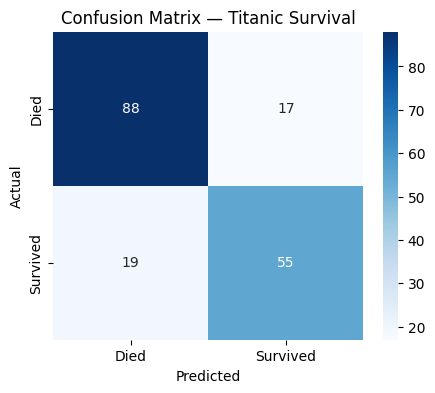


🔎 ANALYSIS:
- Logistic Regression was used to predict survival on the Titanic dataset.




In [1]:


import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt


titanic = sns.load_dataset('titanic')


print(titanic.head())


data = titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked']]

data['age'].fillna(data['age'].median(), inplace=True)
data['embarked'].fillna(data['embarked'].mode()[0], inplace=True)


data = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)


print(data.head())



X = data.drop('survived', axis=1)
y = data['survived']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)



y_pred = model.predict(X_test)


accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\n  Model Accuracy: {accuracy:.2f}")
print("\n  Confusion Matrix:\n", cm)
print("\n  Classification Report:\n", report)

# Plot Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Titanic Survival')
plt.show()


print("""
🔎 ANALYSIS:
- Logistic Regression was used to predict survival on the Titanic dataset.

""".format(accuracy))
